In [ ]:
import pandas as pd
import numpy as np
from fredapi import Fred
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

In [166]:
# Insert your FRED API key
fred = Fred(api_key='7c555b88e31520b011cc33e23aba5fb8')

# Define date range
start_date = '2009-11-01'
end_date = '2024-12-31'

# Target variable: WTI crude oil price
wti = fred.get_series('DCOILWTICO', start_date, end_date)

In [ ]:

# Gold futures (COMEX)
gold = yf.download("GC=F", start=start_date, end=end_date)

# Use adjusted close (or Close)
gold_series = gold["Close"]["GC=F"]

[*********************100%***********************]  1 of 1 completed

Date
2009-11-02    1053.400024
2009-11-03    1084.300049
2009-11-04    1086.699951
2009-11-05    1088.699951
2009-11-06    1095.099976
                 ...     
2024-12-23    2612.300049
2024-12-24    2620.000000
2024-12-26    2638.800049
2024-12-27    2617.199951
2024-12-30    2606.100098
Name: GC=F, Length: 3812, dtype: float64


In [ ]:
ovx = yf.download("^OVX", start="2009-11-01", end="2024-12-31")
oil_volatility = ovx['Close']['^OVX']

[*********************100%***********************]  1 of 1 completed


Date
2009-11-02    41.779999
2009-11-03    41.580002
2009-11-04    40.599998
2009-11-05    38.980000
2009-11-06    38.700001
                ...    
2024-12-23    30.160000
2024-12-24    30.350000
2024-12-26    30.010000
2024-12-27    30.209999
2024-12-30    30.770000
Name: ^OVX, Length: 3815, dtype: float64

In [169]:
# Interest Rates
y3 = fred.get_series('DGS3', start_date, end_date)   # 3-Year Treasury
y10 = fred.get_series('DGS10', start_date, end_date) # 10-Year Treasury

# Yield Spread (10Y - 3Y)
yield_spread = y10 - y3

# Industrial Production
indpro = fred.get_series('INDPRO', "2009-11-01", end_date)

In [170]:
# S&P 500 index
#sp500 = fred.get_series('SP500', start_date, end_date)

# VIX volatility index
vix = fred.get_series('VIXCLS', start_date, end_date)

# USD index (Trade Weighted Dollar Index)
usd = fred.get_series('DTWEXBGS', start_date, end_date)



In [171]:
sp500 = yf.download("^GSPC", start=start_date, end=end_date)
sp500=sp500["Close"]['^GSPC']


[*********************100%***********************]  1 of 1 completed


- The S&P 500 (Standard & Poor's 500 Index) is a market-capitalization-weighted index tracking 500 of the largest publicly traded U.S. companies. It is a premier benchmark for the overall health of the US economy and stock market, representing roughly 80% of the total market value.
- The CBOE Volatility Index (VIX) is a real-time market index that acts as a "fear gauge," measuring expected 30-day volatility for the S&P 500 index. It predicts market risk and investor sentiment by tracking options prices, usually moving inversely to the S&P 500—rising during uncertainty and falling during stability
- West Texas Intermediate (WTI) is a high-quality, light, and sweet crude oil that serves as a primary benchmark for oil pricing in the United States
- The U.S. Dollar Index (DXY) is a measure of the value of the U.S. dollar relative to a basket of six major foreign currencies: the Euro (EUR), Japanese Yen (JPY), British Pound (GBP), Canadian Dollar (CAD), Swedish Krona (SEK), and Swiss Franc (CHF)
- Crude oil inventory refers to the total stock of unrefined petroleum currently stored in tanks, pipelines, and terminals by producing nations, refiners, and commercial operators.


In [172]:
for df in [wti, sp500, vix, usd, gold_series, yield_spread, oil_volatility]:
    df.index = pd.to_datetime(df.index)
    df.sort_index(inplace=True)

In [173]:
data = pd.concat(
    [wti, sp500, vix, usd, gold_series, yield_spread, oil_volatility],
    axis=1,
    join='outer'
)

In [174]:
data.columns = ['WTI', 'SP500', 'VIX', 'USD', "Gold", "Yield", "Oil_Volatility"]
data

,WTI,SP500,VIX,USD,Gold,Yield,Oil_Volatility
2009-11-02,78.08,1042.880005,29.78,92.4501,1053.400024,2.01,41.779999
2009-11-03,79.58,1045.410034,28.81,92.9037,1084.300049,2.04,41.580002
2009-11-04,80.30,1046.500000,27.72,92.3725,1086.699951,2.11,40.599998
2009-11-05,79.64,1066.630005,25.43,92.3437,1088.699951,2.13,38.980000
2009-11-06,77.40,1069.300049,24.19,92.3848,1095.099976,2.14,38.700001
...,...,...,...,...,...,...,...
2024-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-12-26,70.38,6037.589844,14.73,128.3329,2638.800049,0.23,30.010000
2024-12-27,71.28,5970.839844,15.95,128.4500,2617.199951,0.26,30.209999
2024-12-30,71.73,5906.939941,17.40,128.8205,2606.100098,0.26,30.770000


In [175]:
indpro_release = indpro.copy()

# shift to end of month
indpro_release.index = indpro_release.index + pd.offsets.MonthEnd(0)

# add ~15 days release lag (approximation)
indpro_release.index = indpro_release.index + pd.Timedelta(days=15)

data['INDPRO'] = indpro_release.reindex(data.index).ffill()

In [176]:
indpro_release

2009-12-15     88.0221
2010-01-15     88.3793
2010-02-15     89.3426
2010-03-15     89.6779
2010-04-15     90.2928
                ...   
2024-09-15    100.4309
2024-10-15     99.8084
2024-11-15     99.4695
2024-12-15     99.2925
2025-01-15    100.3273
Length: 182, dtype: float64

In [ ]:
data.index.name = "Date"
#get data just from 2010
data=data.loc[data.index>"2009-12-31"]

,WTI,SP500,VIX,USD,Gold,Yield,Oil_Volatility,INDPRO
Date,,,,,,,,
2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,88.0221
2010-01-04,81.52,1132.989990,20.04,92.3566,1117.699951,2.19,35.439999,88.0221
2010-01-05,81.74,1136.520020,19.35,92.2236,1118.099976,2.20,34.270000,88.0221
2010-01-06,83.12,1137.140015,19.16,92.0941,1135.900024,2.25,34.400002,88.0221
2010-01-07,82.60,1141.689941,19.06,92.3684,1133.099976,2.23,33.610001,88.0221
...,...,...,...,...,...,...,...,...
2024-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,99.4695
2024-12-26,70.38,6037.589844,14.73,128.3329,2638.800049,0.23,30.010000,99.4695
2024-12-27,71.28,5970.839844,15.95,128.4500,2617.199951,0.26,30.209999,99.4695


In [179]:
data.to_csv("wti_data.csv", index=True)

In [180]:
print(data.shape)
print(data.info())
print(data.isna().sum())

(3913, 8)
<class 'pandas.DataFrame'>
DatetimeIndex: 3913 entries, 2010-01-01 to 2024-12-31
Freq: B
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   WTI             3765 non-null   float64
 1   SP500           3773 non-null   float64
 2   VIX             3793 non-null   float64
 3   USD             3732 non-null   float64
 4   Gold            3770 non-null   float64
 5   Yield           3752 non-null   float64
 6   Oil_Volatility  3773 non-null   float64
 7   INDPRO          3913 non-null   float64
dtypes: float64(8)
memory usage: 275.1 KB
None
WTI               148
SP500             140
VIX               120
USD               181
Gold              143
Yield             161
Oil_Volatility    140
INDPRO              0
dtype: int64


In [ ]:
data.describe()

               WTI        SP500          VIX          USD         Gold  \
count  3765.000000  3773.000000  3793.000000  3732.000000  3770.000000   
mean     72.073995  2727.439112    18.373905   107.910123  1544.688089   
std      21.475895  1264.115621     6.958175    11.879190   350.965404   
min     -36.980000  1022.580017     9.140000    85.469200  1050.800049   
25%      53.290000  1701.839966    13.600000    93.915325  1260.699951   
50%      73.140000  2431.770020    16.590000   112.097750  1435.800049   
75%      89.560000  3818.800049    21.160000   116.730975  1784.700012   
max     123.640000  6090.270020    82.690000   129.277500  2788.500000   

             Yield  Oil_Volatility       INDPRO  
count  3752.000000     3773.000000  3913.000000  
mean      0.880989       37.015550    99.017619  
std       0.794384       17.005452     3.620591  
min      -0.730000       14.500000    84.561900  
25%       0.210000       28.580000    97.871300  
50%       0.850000       34.04999

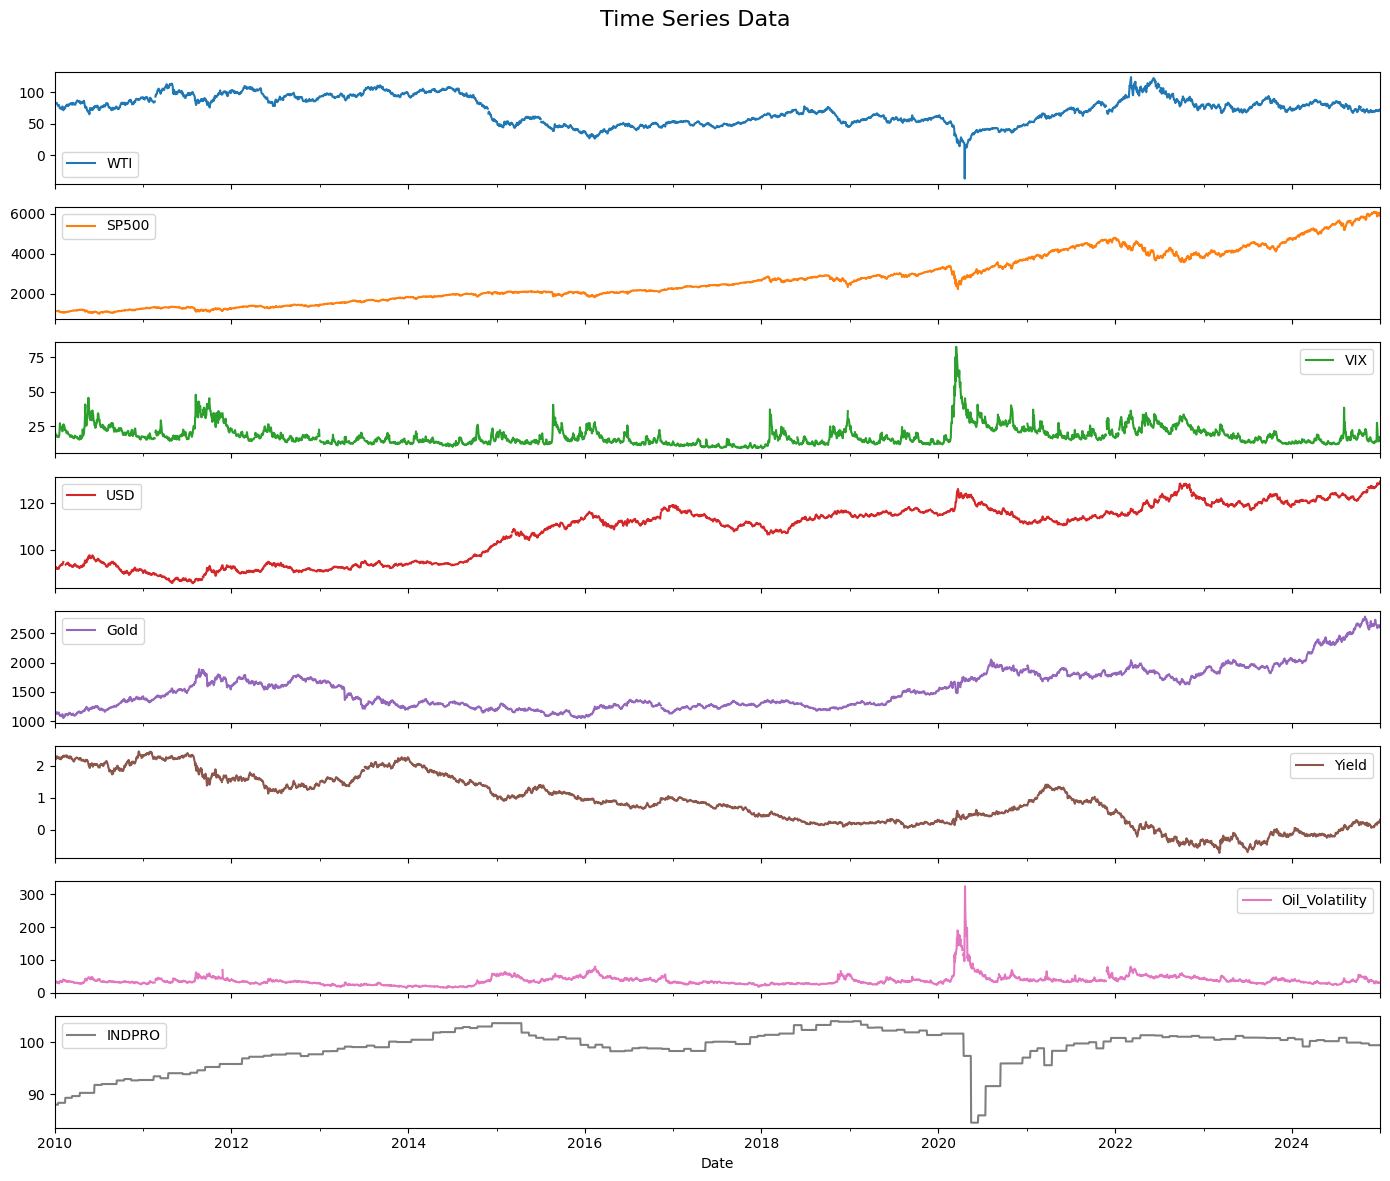

In [ ]:
axes = data.plot(subplots=True, figsize=(14, 12))

fig = axes[0].get_figure()
fig.suptitle("Time Series plots of raw data", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

The Raw Variables have obvious Trends, Structural Breaks & High Volatility Periods. There was a notable Disruption in the 2020 COVID-19 Crisis Where All Four Variables (WTI Price, VIX, OVX & Industrial Production) Experienced A Significant Shock. It's Obvious That all four variables are Non-Stationary and Will Need to be Transformed Before Modeling.

## Market & Macro Indicators Overview (2010–2024)

This figure compares several major financial and economic indicators over time and highlights how markets react to economic uncertainty and global events.

- **WTI Oil Prices:** Oil prices fluctuate significantly due to supply-demand shocks, geopolitical tensions, and global crises. The sharp collapse in 2020 reflects the COVID-19 demand shock.

- **S&P 500:** The stock market shows a strong long-term upward trend despite temporary declines during periods of uncertainty, especially in 2020.

- **VIX (Volatility Index):** The VIX measures market fear and uncertainty. Large spikes, particularly in 2020, indicate periods of high financial stress.

- **USD Index:** The U.S. dollar generally strengthened over time, especially during crises when investors moved toward safe-haven assets.

- **Gold Prices:** Gold trends upward over the long run as investors seek protection against inflation and economic instability.

- **Treasury Yield:** Bond yields generally declined over the decade, reflecting lower interest rates and slower economic growth expectations.

- **Oil Volatility:** Oil market volatility spikes during major disruptions, with the largest surge occurring during the COVID-19 pandemic.

- **Industrial Production (INDPRO):** Industrial production grew gradually before experiencing a sharp decline in 2020 due to economic shutdowns, followed by recovery afterward.

Overall, the chart illustrates the interconnected relationship between financial markets, commodities, investor sentiment, and macroeconomic activity.

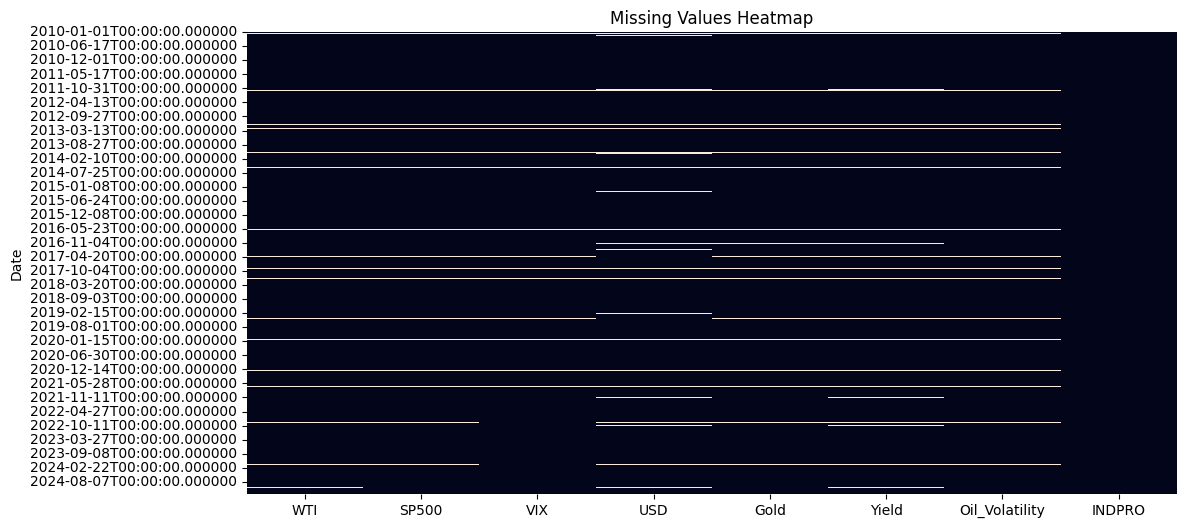

In [ ]:
plt.figure(figsize=(12,6))
sns.heatmap(data.isna(), cbar=False)
plt.title("Missing Values Heatmap of raw data")
plt.show()

Missing values are limited and primarily occur on market holidays and non-trading days. The overall dataset is largely complete, indicating that only minor preprocessing and imputation are required before analysis.

In [184]:
#check for duplicates 
print(data.index.duplicated().sum())

0


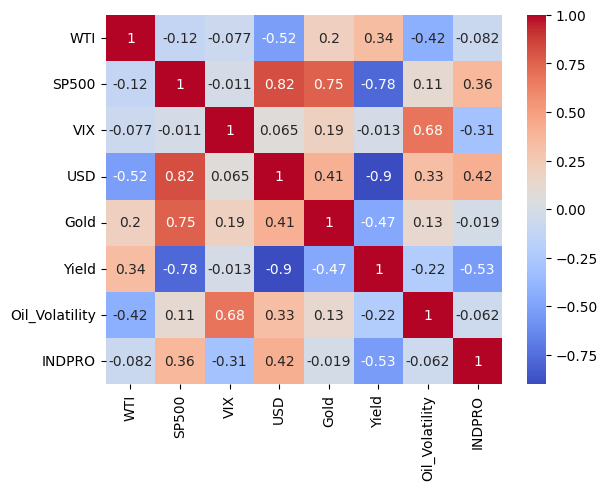

In [ ]:
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation of raw data")
plt.show()

The correlation matrix reveals several economically meaningful relationships. Equity and oil market variables show positive associations, while volatility indicators generally exhibit negative relationships with market performance. However, correlations alone do not capture potential nonlinear dependencies.

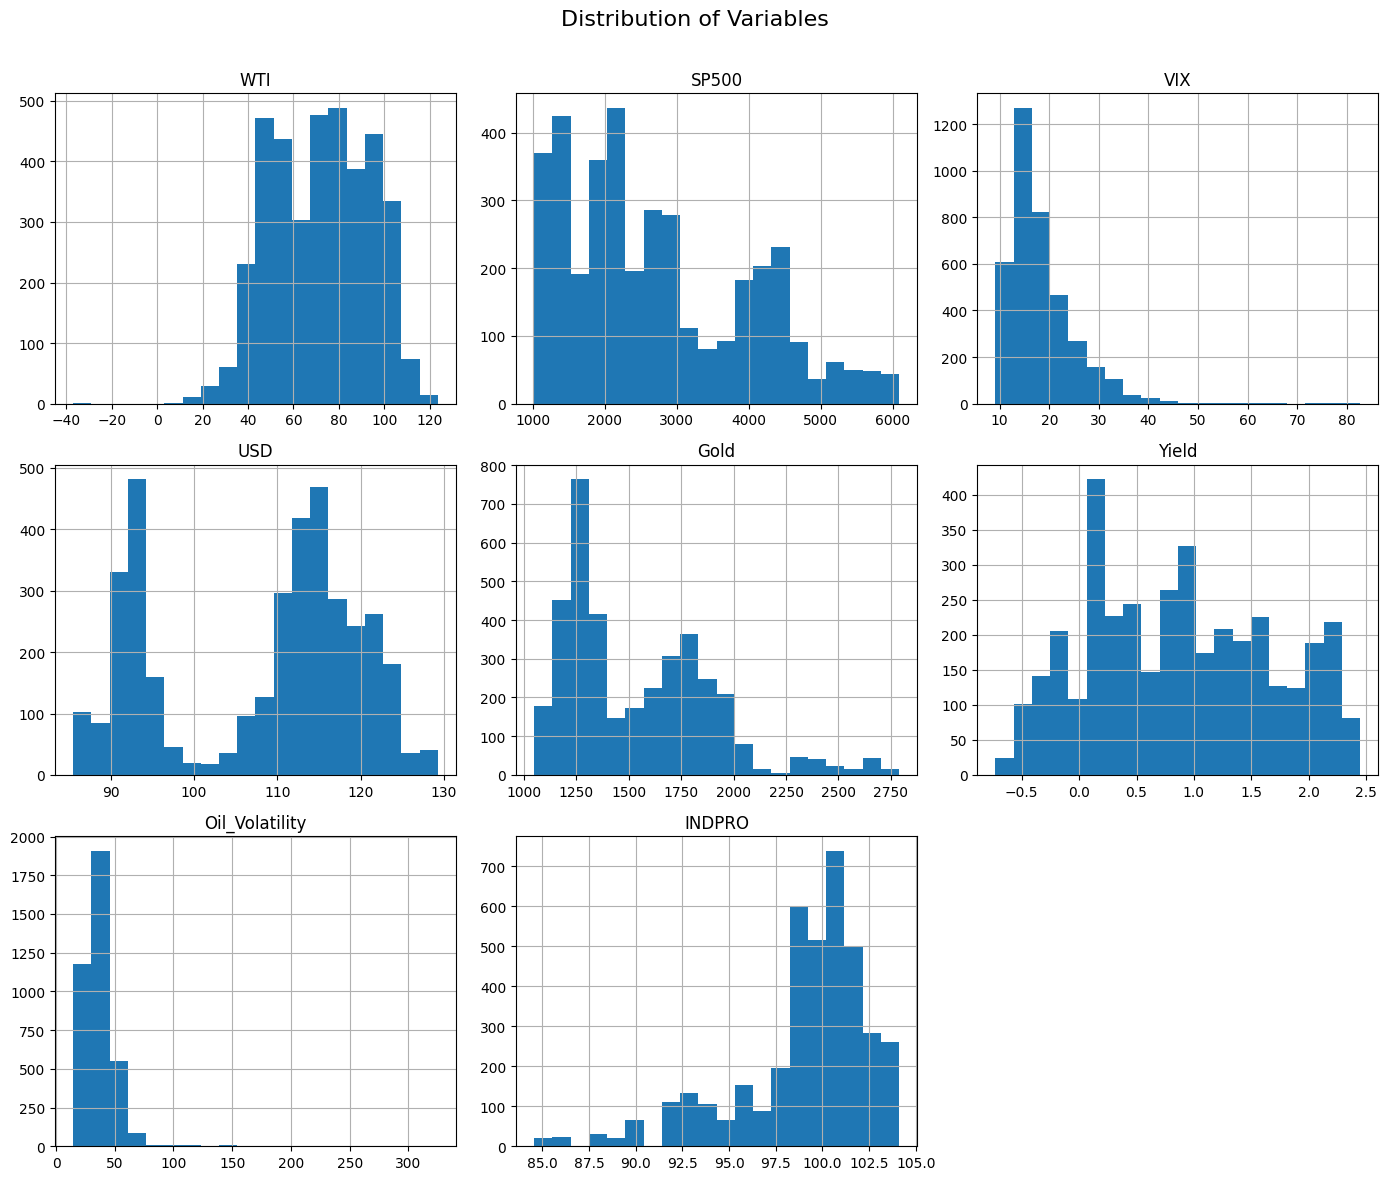

In [ ]:
data.hist(figsize=(14, 12), bins=20)

plt.suptitle("Distribution of raw data", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])  
plt.show()

MOST RAW VARIABLES HAVE Distributions that are SKewed AND Not Normal. VIX and OVX have long right tail distributions due to times of crisis and also large value range in time for many types of financial assets like gold, wti, s&p 500; therefore this is an additional reason to transform your data.

In [188]:
# Replace inf values first
data = data.replace([np.inf, -np.inf], np.nan)

# Remove invalid non-positive values
data.loc[data['WTI'] == 0, 'WTI'] = np.nan
data.loc[data['SP500'] <= 0, 'SP500'] = np.nan
data.loc[data['USD'] <= 0, 'USD'] = np.nan
data.loc[data['Gold'] <= 0, 'Gold'] = np.nan
data.loc[data['VIX'] < 0, 'VIX'] = np.nan
data.loc[data['Oil_Volatility'] < 0, 'Oil_Volatility'] = np.nan

In [189]:
results = []
temp=data

for col in temp.columns:
    result = adfuller(temp[col].dropna())
    
    results.append({
        'Variable': col,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 4),
        'Conclusion': 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    })

# Convert to DataFrame
adf_table = pd.DataFrame(results)
adf_table = adf_table.sort_values(by='p-value')
# Display nicely
adf_table

,Variable,ADF Statistic,p-value,Conclusion
2,VIX,-5.2520,0.0000,Stationary
6,Oil_Volatility,-6.4773,0.0000,Stationary
7,INDPRO,-3.6066,0.0056,Stationary
0,WTI,-2.3670,0.1513,Non-stationary
5,Yield,-1.6636,0.4500,Non-stationary
3,USD,-0.5572,0.8804,Non-stationary
4,Gold,0.0383,0.9616,Non-stationary
1,SP500,1.4265,0.9972,Non-stationary


In [190]:
# Sort data
data = data.sort_index()

#  Remove duplicates
data = data[~data.index.duplicated(keep='first')]

# Convert to numeric
data = data.apply(pd.to_numeric, errors='coerce')

# Convert to weekly frequency
data_weekly = data.resample('W-FRI').last()

# Handle missing values
# Forward-fill small gaps
data_weekly = data_weekly.ffill(limit=2)

# Remove remaining missing rows
data_weekly = data_weekly.dropna()

# LOG RETURNS
returns = pd.DataFrame()
returns['WTI'] = np.log(data_weekly['WTI'] / data_weekly['WTI'].shift(1))
returns['SP500'] = np.log(data_weekly['SP500'] / data_weekly['SP500'].shift(1))
returns['USD'] = np.log(data_weekly['USD'] / data_weekly['USD'].shift(1))
returns['Gold'] = np.log(data_weekly['Gold'] / data_weekly['Gold'].shift(1))

# DIFFERENCES
returns['VIX_diff'] = data_weekly['VIX'].diff()
returns['OVX_diff'] = data_weekly['Oil_Volatility'].diff()
returns['Yield_diff'] = data_weekly['Yield'].diff()

# PERCENTAGE CHANGE
returns['INDPRO_pct'] = data_weekly['INDPRO'].pct_change()

# LAGGED FEATURES
returns['WTI_lag1'] = returns['WTI'].shift(1)
returns['WTI_lag2'] = returns['WTI'].shift(2)

# TARGET VARIABLE
returns['Target'] = returns['WTI'].shift(-1)

# FINAL DATASET
model_data = returns.dropna()

In [223]:
model_data.head()

,WTI,SP500,USD,Gold,VIX_diff,OVX_diff,Yield_diff,INDPRO_pct,WTI_lag1,WTI_lag2,Target
Date,,,,,,,,,,,
2010-01-29,-0.019035,-0.016522,0.008792,-0.005708,-2.69,-0.799999,2.000000e-02,0.0000,-0.048758,-0.059507,-0.023612
2010-02-05,-0.023612,-0.007177,0.009109,-0.028852,1.49,5.940002,6.000000e-02,0.0000,-0.019035,-0.048758,0.040760
2010-02-12,0.040760,0.008703,-0.006619,0.034836,-3.38,-3.950001,4.440892e-16,0.0000,-0.023612,-0.019035,0.073597
2010-02-19,0.073597,0.030817,-0.000433,0.028770,-2.71,-1.410000,-4.000000e-02,0.0109,0.040760,-0.023612,-0.000627
2010-02-26,-0.000627,-0.004228,-0.003163,-0.002679,-0.52,-1.810001,-2.000000e-02,0.0000,0.073597,0.040760,0.022083


In [192]:
model_data.to_csv("model_data.csv", index=True)

In [193]:
data_weekly.isna().sum()

WTI               0
SP500             0
VIX               0
USD               0
Gold              0
Yield             0
Oil_Volatility    0
INDPRO            0
dtype: int64

In [194]:
z_scores = (returns - returns.mean()) / returns.std()

outliers = np.abs(z_scores) > 4

outlier_counts = outliers.sum()

print(outlier_counts)

WTI           4
SP500         5
USD           2
Gold          3
VIX_diff      5
OVX_diff      8
Yield_diff    2
INDPRO_pct    6
WTI_lag1      4
WTI_lag2      4
Target        4
dtype: int64


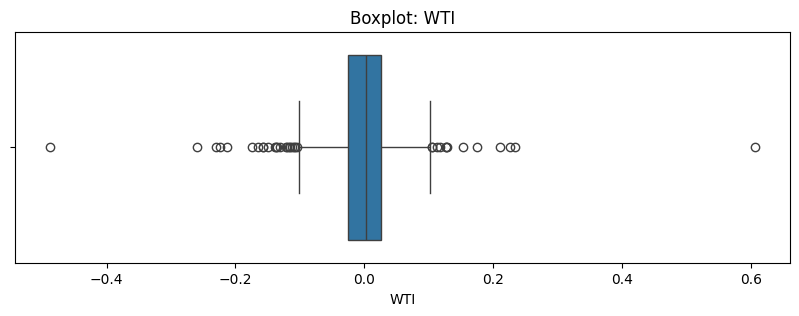

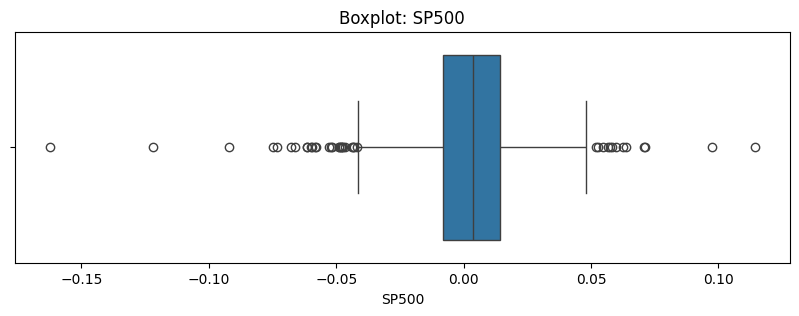

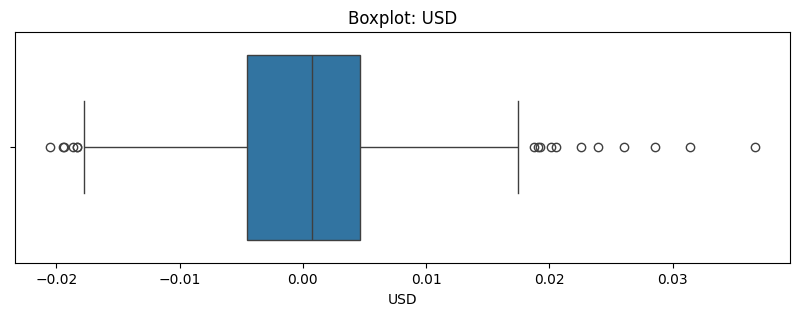

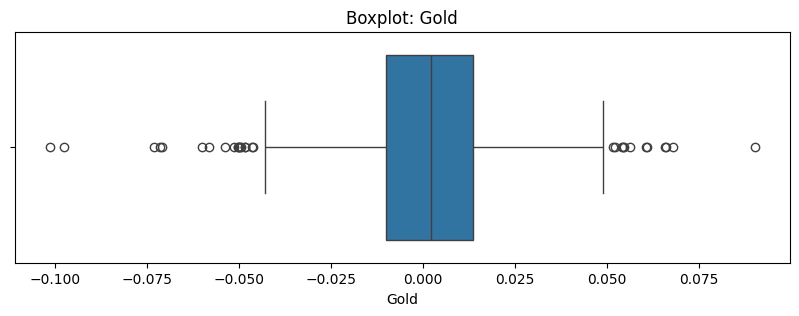

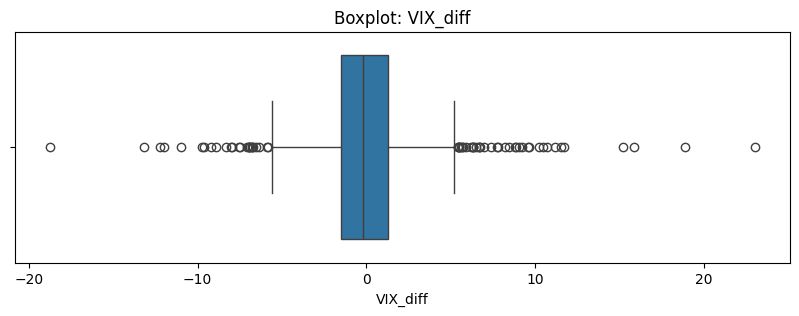

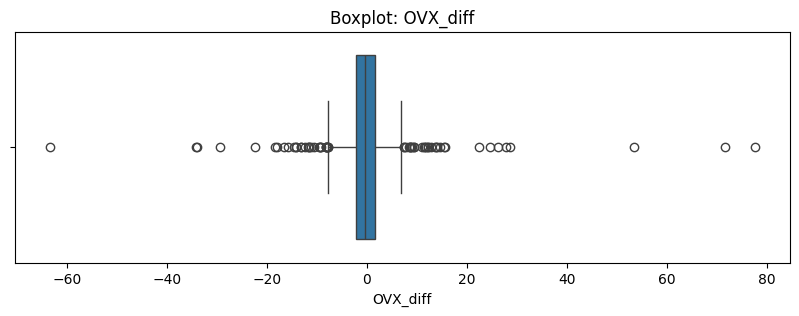

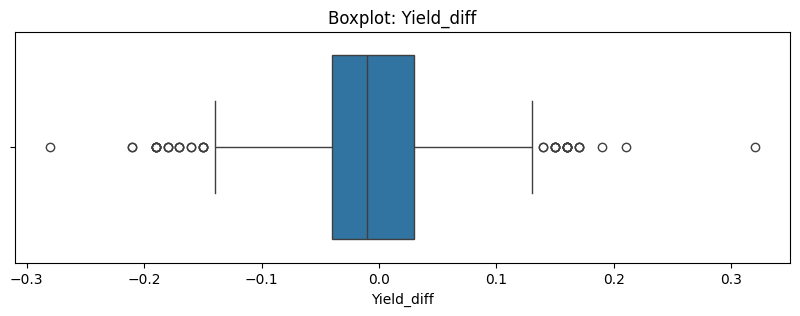

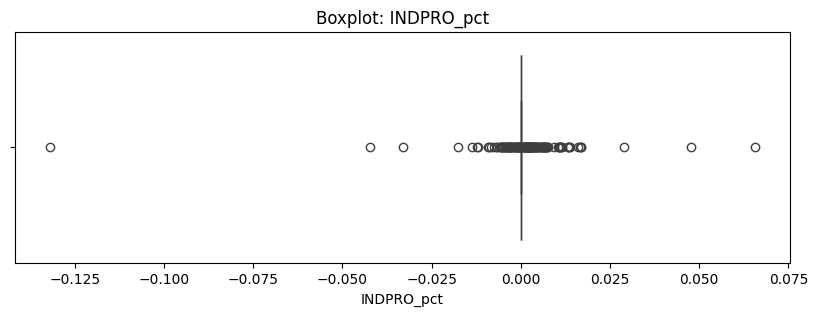

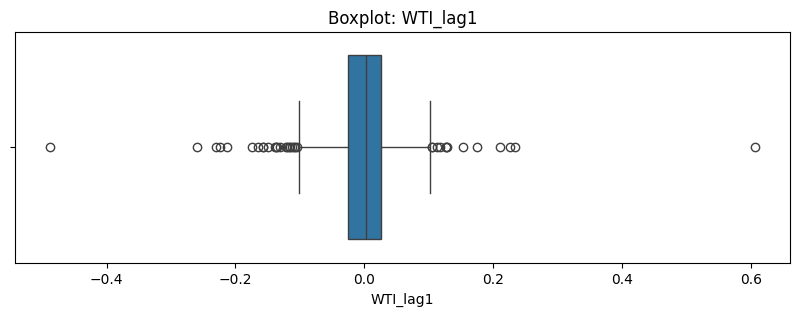

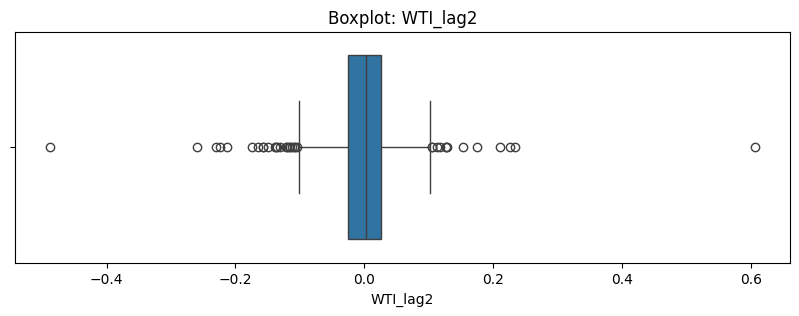

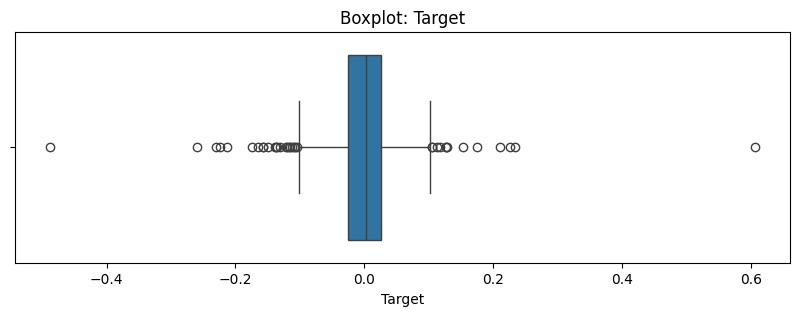

In [195]:
for col in model_data.columns:
    plt.figure(figsize=(10,3))
    
    sns.boxplot(x=model_data[col])
    
    plt.title(f'Boxplot: {col}')
    plt.show()

All returns appear to be skewed and conatins outliers 

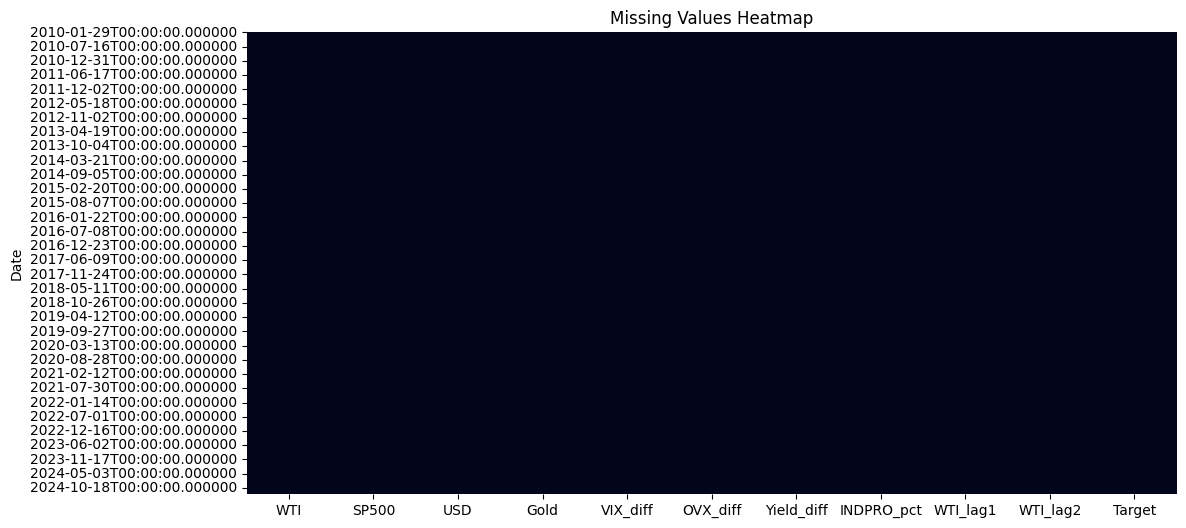

In [196]:


plt.figure(figsize=(12,6))
sns.heatmap(model_data.isna(), cbar=False)

plt.title("Missing Values Heatmap")
plt.show()

In [197]:
model_data.index.duplicated().sum()

np.int64(0)

In [198]:
model_data.dtypes

WTI           float64
SP500         float64
USD           float64
Gold          float64
VIX_diff      float64
OVX_diff      float64
Yield_diff    float64
INDPRO_pct    float64
WTI_lag1      float64
WTI_lag2      float64
Target        float64
dtype: object

In [199]:
summary = model_data.describe().T

summary['skew'] = model_data.skew()
summary['kurtosis'] = model_data.kurtosis()

summary

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
WTI,779.0,-0.000052,0.057729,-0.487559,-0.025124,0.002533,0.026348,0.605431,0.438074,23.178488
SP500,779.0,0.002181,0.022587,-0.162279,-0.008079,0.003653,0.014359,0.114237,-0.789971,6.360198
USD,779.0,0.000415,0.007183,-0.020503,-0.004510,0.000787,0.004604,0.036661,0.386339,1.523635
Gold,779.0,0.001125,0.021376,-0.101316,-0.010098,0.002125,0.013557,0.090090,-0.275456,1.887471
VIX_diff,779.0,-0.014583,3.335876,-18.740000,-1.480000,-0.190000,1.265000,23.030000,0.767549,7.729657
OVX_diff,779.0,-0.005956,6.966134,-63.349998,-2.065000,-0.250000,1.695001,77.619995,2.648541,48.823570
Yield_diff,779.0,-0.002529,0.064769,-0.280000,-0.040000,-0.010000,0.030000,0.320000,0.051025,1.827119
INDPRO_pct,779.0,0.000174,0.006510,-0.131878,0.000000,0.000000,0.000000,0.065530,-9.253524,237.353238
WTI_lag1,779.0,-0.000144,0.057750,-0.487559,-0.025228,0.002520,0.026348,0.605431,0.441502,23.144217
WTI_lag2,779.0,-0.000187,0.057781,-0.487559,-0.025228,0.002520,0.026348,0.605431,0.441736,23.089394




* **count**: Number of observations in the dataset. All variables contain 779 data points.

* **mean**: The average value of the variable. Most means are close to zero, suggesting returns and changes fluctuate around a stable average.

* **std (standard deviation)**: Measures volatility or dispersion. Higher values indicate greater variability. For example, `OVX_diff` has high volatility compared to `USD`.

* **min**: The lowest observed value in the dataset.

* **25% (Q1)**: The first quartile. 25% of observations fall below this value.

* **50% (median)**: The middle value of the distribution.

* **75% (Q3)**: The third quartile. 75% of observations fall below this value.

* **max**: The highest observed value.

* **skew**: Measures asymmetry in the distribution.

  * Positive skew → longer right tail.
  * Negative skew → longer left tail.
    For example, `OVX_diff` is highly positively skewed.

* **kurtosis**: Measures the heaviness of tails and presence of extreme values.

  * High kurtosis indicates more extreme observations/outliers.
  * Variables like `INDPRO_pct` and `OVX_diff` show very high kurtosis, suggesting extreme market events or shocks.

> Overall, the descriptive statistics suggest that several financial variables exhibit high volatility, skewness, and kurtosis, indicating non-normal and nonlinear behaviour commonly observed in financial time-series data.


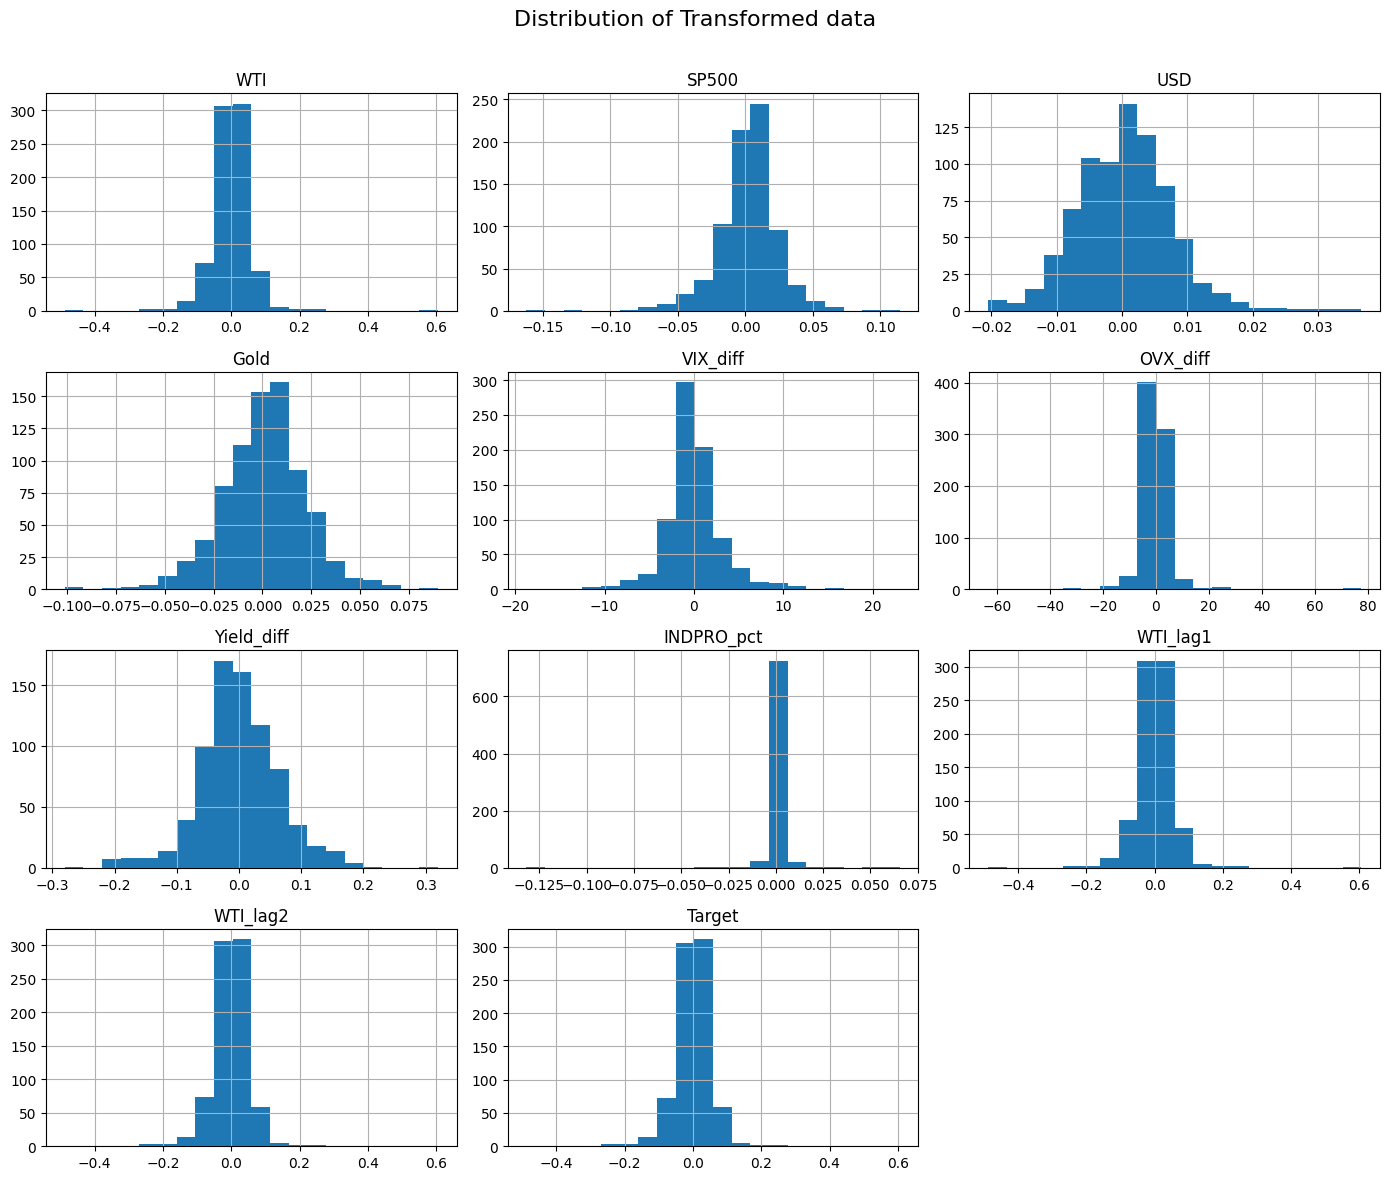

In [224]:
model_data.hist(figsize=(14, 12), bins=20)

plt.suptitle("Distribution of Transformed data", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])  
plt.show()

The transformed variables are more centered around zero and display distributions that are closer to normality. Some variables retain heavier tails due to extreme market events, but the transformations significantly reduce skewness and scale differences.

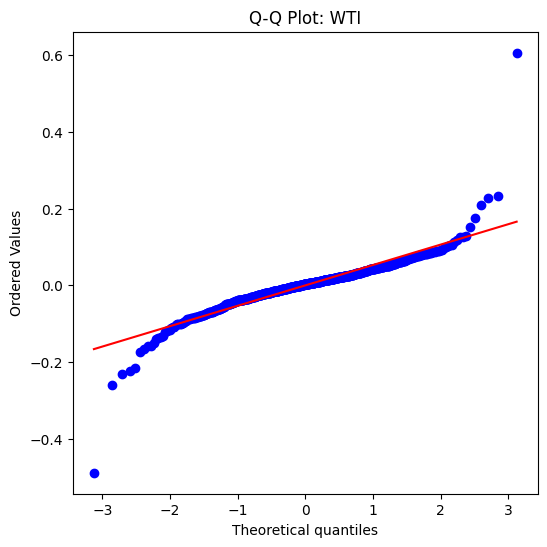

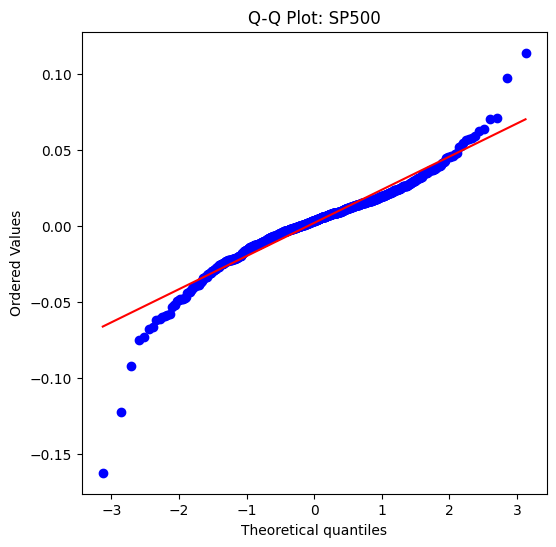

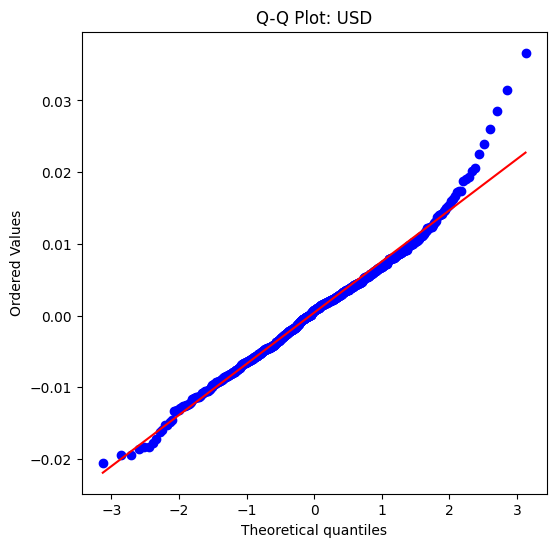

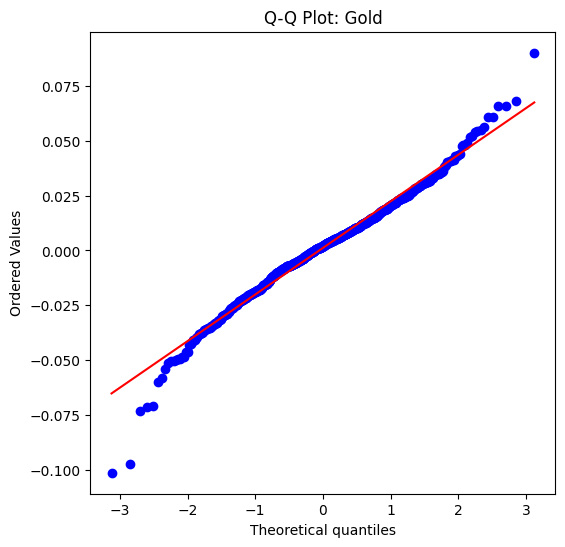

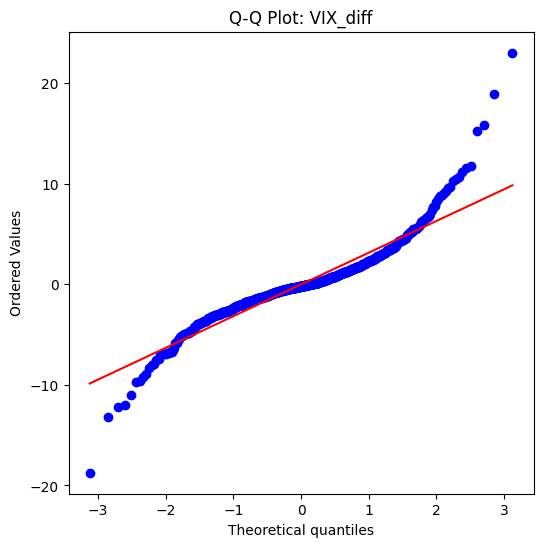

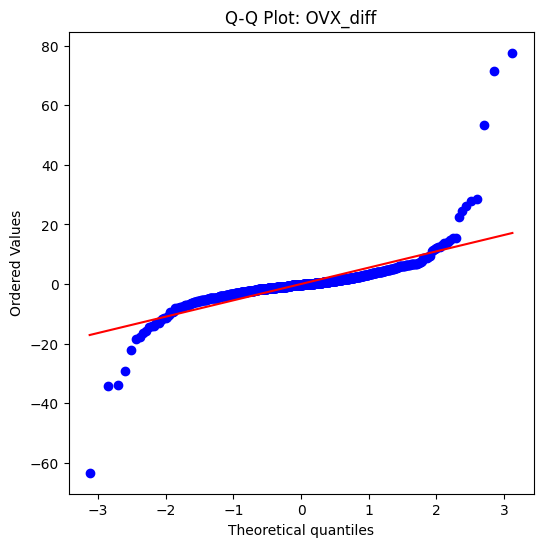

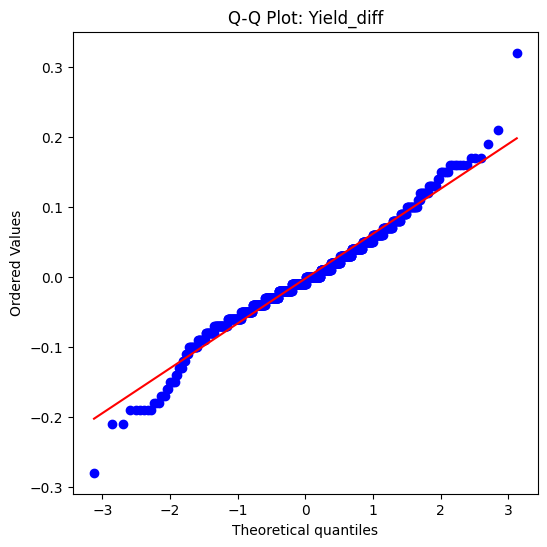

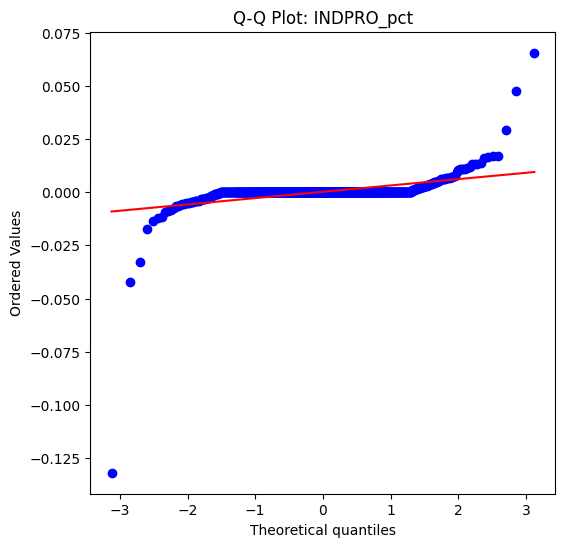

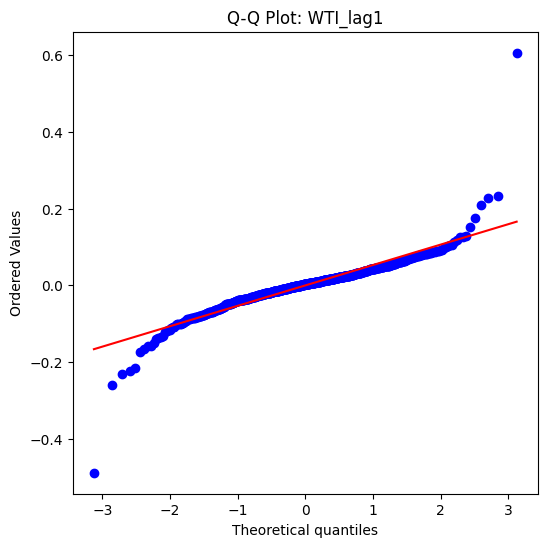

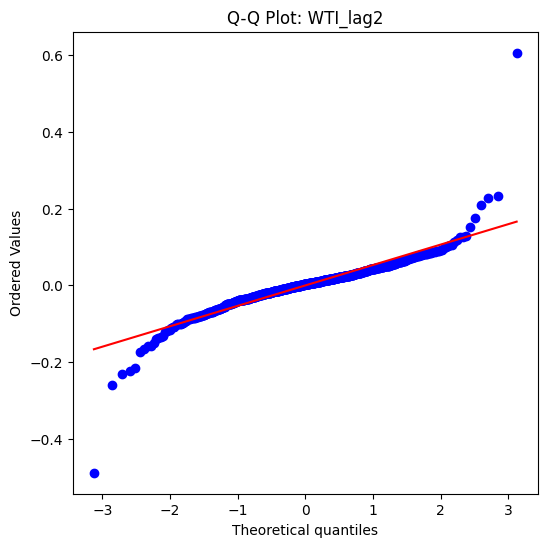

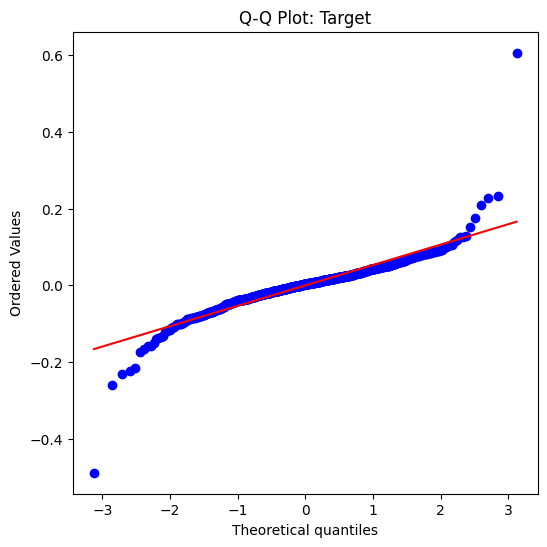

In [ ]:
for col in model_data.columns:
    plt.figure(figsize=(6,6))
    
    stats.probplot(model_data[col], dist="norm", plot=plt)
    
    plt.title(f'Q-Q Plot: {col}')
    plt.show()

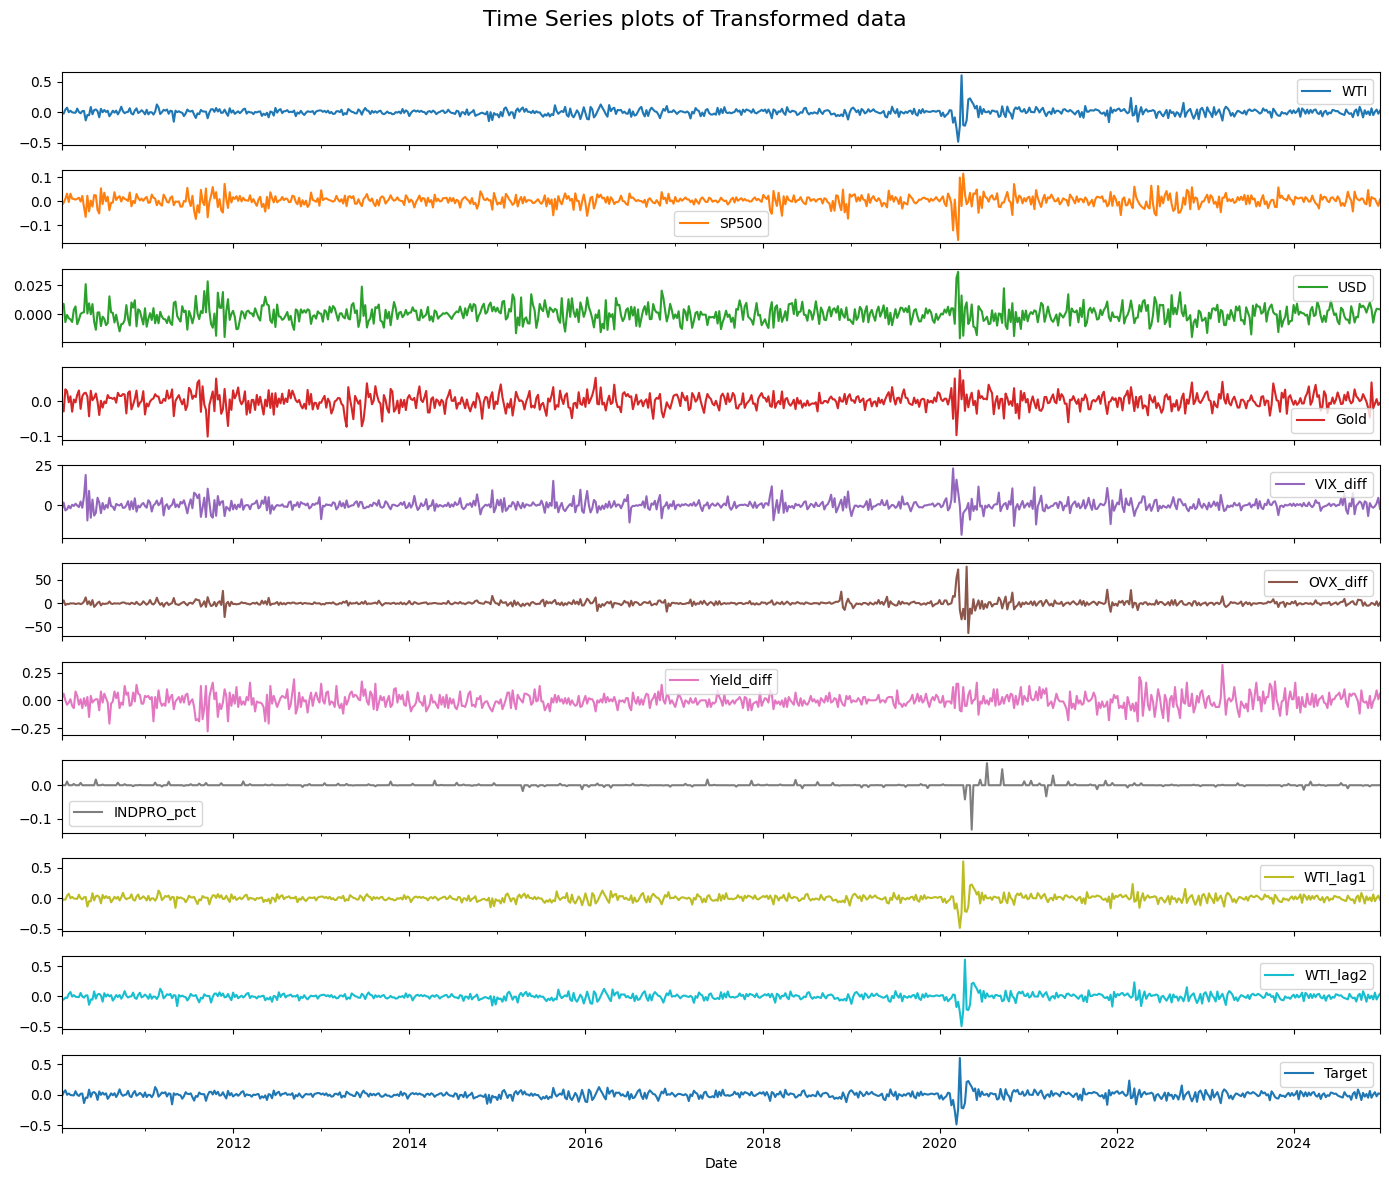

In [225]:
axes = model_data.plot(subplots=True, figsize=(14, 12))

fig = axes[0].get_figure()
fig.suptitle("Time Series plots of Transformed data", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

After adjusting data (returns, differences and % changes), all of the time series are fluctuating around a nearly constant mean approximately equal to zero. The volatility clustering can still be observed with an increased visibility in the year 2020. Therefore, after removing the trend, we observe that these time series look like they could be modelled using statistical models. In order to confirm this assumption, it is necessary to run ADF tests.

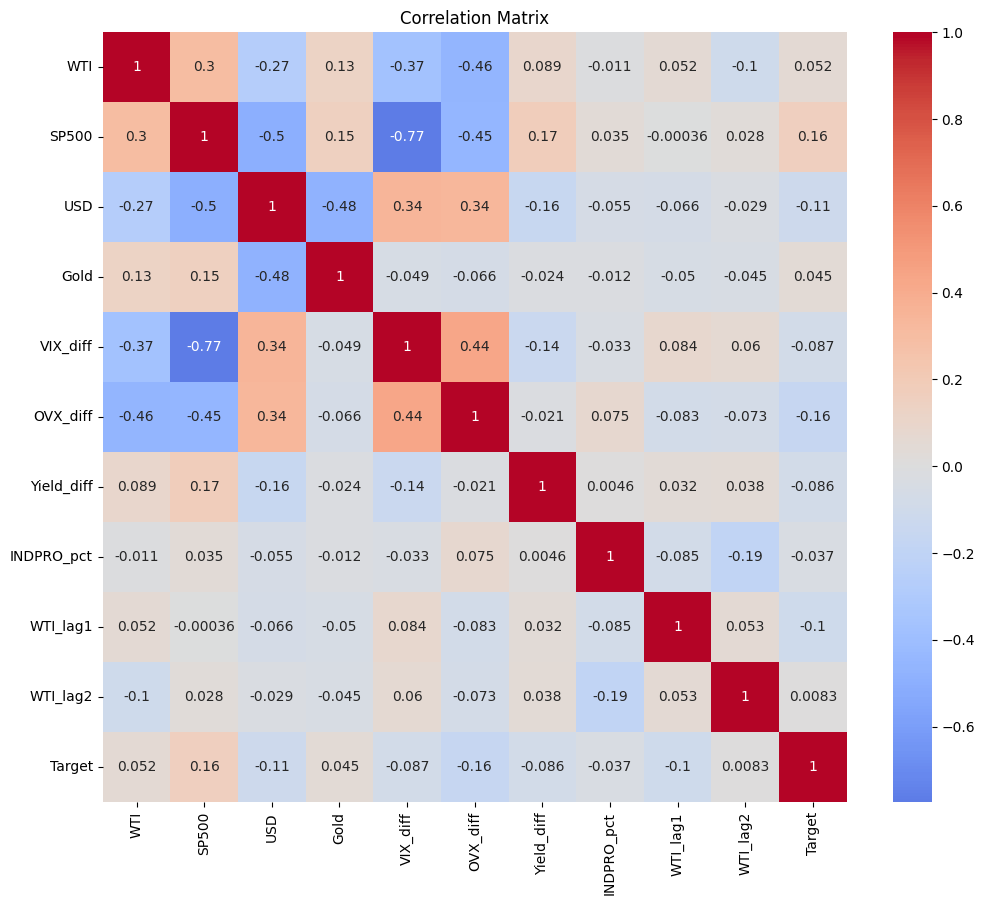

In [ ]:
corr = model_data.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of transformed data')
plt.show()

In terms of predictor-target correlations, they were generally small in magnitude as would be expected when attempting to predict financial returns. 
This also supports the need for using machine learning models, as they can identify non-linear patterns within data, and there does appear to be some degree of non-linearity in the relationship between each predictor and the target variable.

In [206]:
corr['Target'].sort_values(ascending=False)

Target        1.000000
SP500         0.156089
WTI           0.051632
Gold          0.044720
WTI_lag2      0.008284
INDPRO_pct   -0.036934
Yield_diff   -0.085742
VIX_diff     -0.087081
WTI_lag1     -0.104829
USD          -0.113661
OVX_diff     -0.163843
Name: Target, dtype: float64

The variables with the strongest relationship with the target variable in descending order is: SP500, WTI, Gold, WTI_lag2, INDPRO_pct, Yield_diff, VIX_diff, WTI_lag1, USD, OVX_diff. 

C:\Users\komet\AppData\Local\Temp\ipykernel_39444\3025616407.py:7: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  data["WTI"].plot(ax=ax2, color="red", label="Raw data")


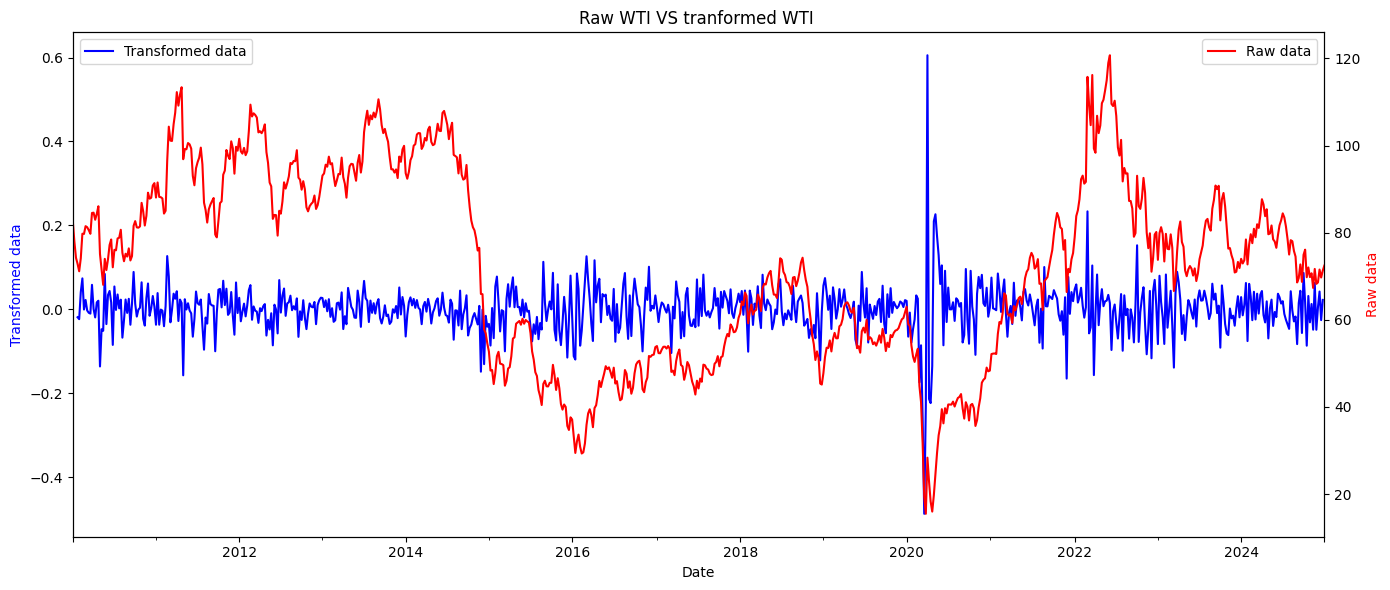

In [227]:
fig, ax1 = plt.subplots(figsize=(14, 6))

model_data["WTI"].plot(ax=ax1, color="blue", label="Transformed data")
ax1.set_ylabel("Transformed data", color="blue")

ax2 = ax1.twinx()
data["WTI"].plot(ax=ax2, color="red", label="Raw data")
ax2.set_ylabel("Raw data", color="red")

ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title("Raw WTI VS tranformed WTI ")
plt.tight_layout()
plt.show()

There is huge difference between raw data and transformed data, raw data is nonstationary while transformed data is stationary. Thereby justifying the transformation. Both plot have very high volatility in 2020

In [209]:
results = []

for col in model_data.columns:
    result = adfuller(model_data[col].dropna())
    
    results.append({
        'Variable': col,
        'ADF Statistic': round(result[0], 4),
        'p-value': round(result[1], 4),
        'Conclusion': 'Stationary' if result[1] < 0.05 else 'Non-stationary'
    })

# Convert to DataFrame
adf_table = pd.DataFrame(results)
adf_table = adf_table.sort_values(by='p-value')
# Display nicely
adf_table

,Variable,ADF Statistic,p-value,Conclusion
0,WTI,-9.8045,0.0,Stationary
1,SP500,-14.3019,0.0,Stationary
2,USD,-27.3380,0.0,Stationary
3,Gold,-17.4913,0.0,Stationary
4,VIX_diff,-12.0293,0.0,Stationary
5,OVX_diff,-9.1753,0.0,Stationary
6,Yield_diff,-7.6818,0.0,Stationary
7,INDPRO_pct,-8.5517,0.0,Stationary
8,WTI_lag1,-9.7877,0.0,Stationary
9,WTI_lag2,-9.7909,0.0,Stationary


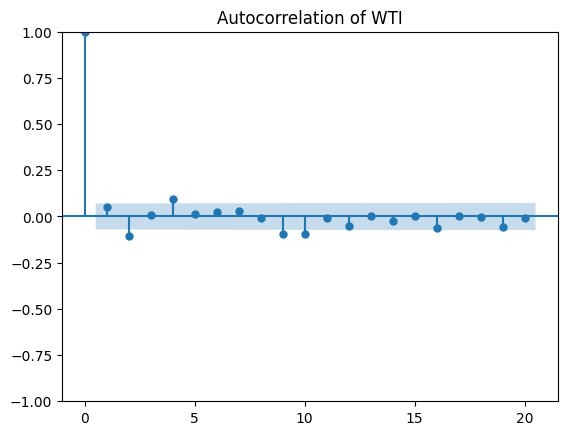

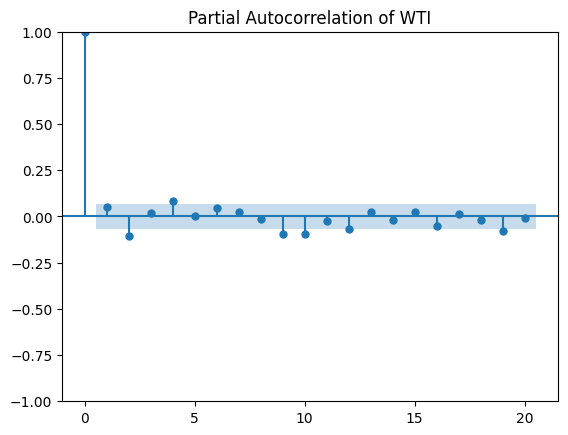

In [229]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(model_data['WTI'], lags=20)
plt.title("Autocorrelation of WTI")
plt.show()

plot_pacf(model_data['WTI'], lags=20)
plt.title("Partial Autocorrelation of WTI")
plt.show()

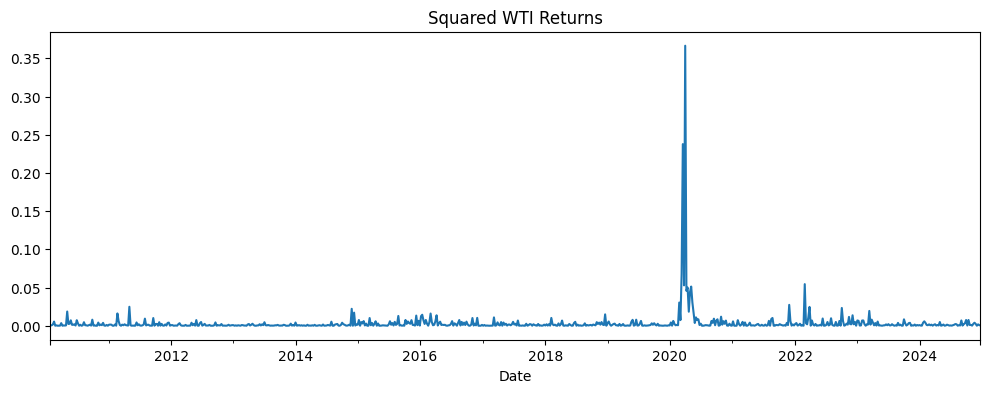

In [211]:
(model_data['WTI']**2).plot(figsize=(12,4))

plt.title('Squared WTI Returns')
plt.show()

The squared WTI returns have been graphed to find how volatility moves over time. It shows that a large amount of volatility is clustered together. That is to say, when there was a lot of price movement in one period, then it will also be very volatile during the next few periods. In other words, this is a common property of many financial time series and demonstrates that we need to allow for heteroskedasticity. Therefore these graphs justify our decision to include both volatility related factors (VIX and OVX) and to model things non-linearly.

In [ ]:
X = model_data.drop(columns=['Target'])

vif = pd.DataFrame()
vif['Feature'] = X.columns

vif['VIF'] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,WTI,1.393174
1,SP500,3.005685
2,USD,1.811274
3,Gold,1.375104
4,VIX_diff,2.787441
5,OVX_diff,1.568978
6,Yield_diff,1.064331
7,INDPRO_pct,1.061101
8,WTI_lag1,1.055615
9,WTI_lag2,1.087022


An examination for Multicollinearity was performed using Variance Inflation Factors (VIF). All predictor variables had a VIF less than five which indicated that there are minimal correlations between each set of features. These results suggest that there is no Multicollinearity within this data; therefore, all of the variables that have been selected provide new information to the model. Based upon the relatively small VIFs it can be inferred that the feature transformation and/or the selection of features has minimized redundant predictive relationships.

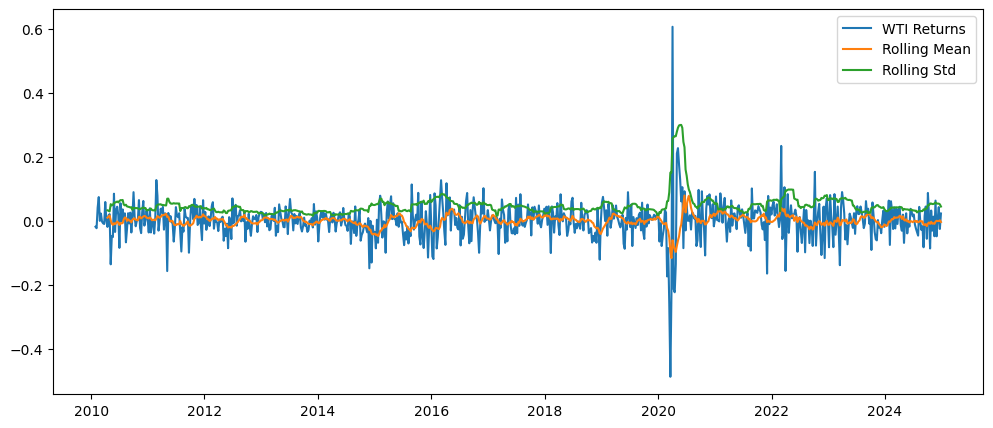

In [213]:
rolling_mean = model_data['WTI'].rolling(12).mean()
rolling_std = model_data['WTI'].rolling(12).std()

plt.figure(figsize=(12,5))

plt.plot(model_data['WTI'], label='WTI Returns')
plt.plot(rolling_mean, label='Rolling Mean')
plt.plot(rolling_std, label='Rolling Std')

plt.legend()
plt.show()

The mean is very consistent for most of the sampling period (the mean doesn't deviate much from zero). This implies that the WTI returns after transformation tend to oscillate about a constant average. The standard deviation tends to vary through time; it was substantially higher than normal for some time in 2020 due to the extraordinary price volatility brought on by the COVID-19 pandemic and a short-term decline in oil prices. In general, this data set has appeared to be relatively stationary in terms of the mean, while clusters of high volatility have been seen as they often are within financial time series.

In [214]:
model_data['OVX_diff'].corr(model_data['Target'])

np.float64(-0.1638432417270139)

In [215]:
for lag in range(1, 6):
    corr = model_data['OVX_diff'].shift(lag).corr(model_data['Target'])
    
    print(f'Lag {lag}: {corr}')

Lag 1: 0.10645111378550663
Lag 2: 0.035165545739884334
Lag 3: -0.11668587842452492
Lag 4: -0.13126684800251395
Lag 5: 0.01225838788516485


A lagged correlation test was performed to find a connection in time between oil price volatility (OVX), and future prices of West Texas Intermediate (WTI) crude. It was found that there are very weak positive correlations of the relationship over all lag periods. The strongest relationship is at one month lag period (.106). The fact that the relationship changes signs on each lag, indicates both an interaction between variables and possibly non-linear relationships. Therefore, although OVX does not appear to have high predictive power in terms of its ability to be related to the forecasted values of WTI using linear methods; it can likely contribute positively to forecasting results if incorporated into nonlinear Machine Learning modeling techniques.

These low levels of lagged correlations also reinforce previous findings from the correlation matrices, supporting the use of non-linear modeling approaches such as tree based methodologies.

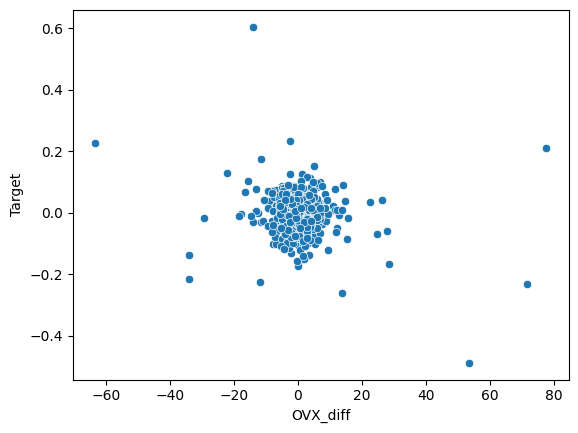

In [ ]:
sns.scatterplot(
    x=model_data['OVX_diff'],
    y=model_data['Target']
)
plt.title("OVX_diff vs Target")
plt.show()

There is no visible pattern between OVX_diff and Target. The presence of no visble pattern justifies the use of Machine learning for modelling.

In [ ]:
#get periods of high vix and periods of low vix.
high_vix = model_data[model_data['VIX_diff'] > 0]
low_vix = model_data[model_data['VIX_diff'] <= 0]

In [ ]:
high_vix['WTI'].mean()

np.float64(0.008697651564823055)

In [235]:
low_vix['WTI'].mean()

np.float64(0.008697651564823055)

In [236]:
high_vix['WTI'].std()

np.float64(0.05861289703911135)

In [237]:
low_vix['WTI'].std()

np.float64(0.05554795411270954)

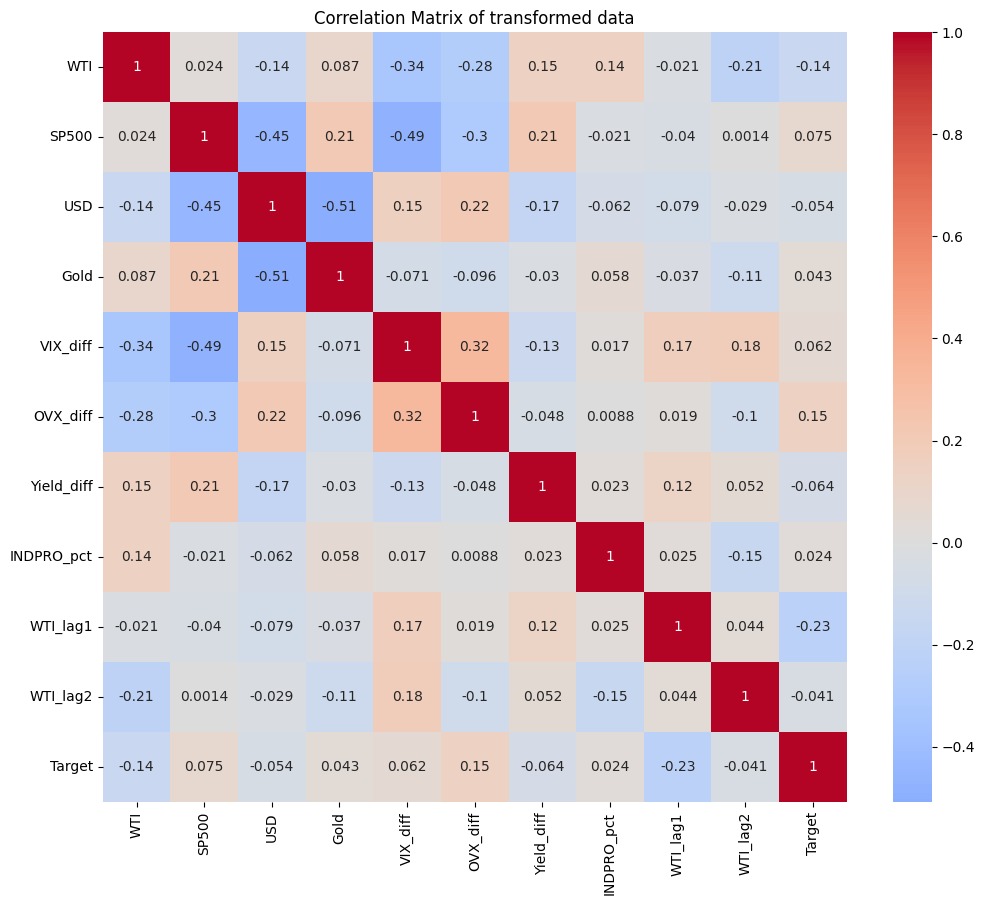

In [233]:

corr=low_vix.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of transformed data')
plt.show()

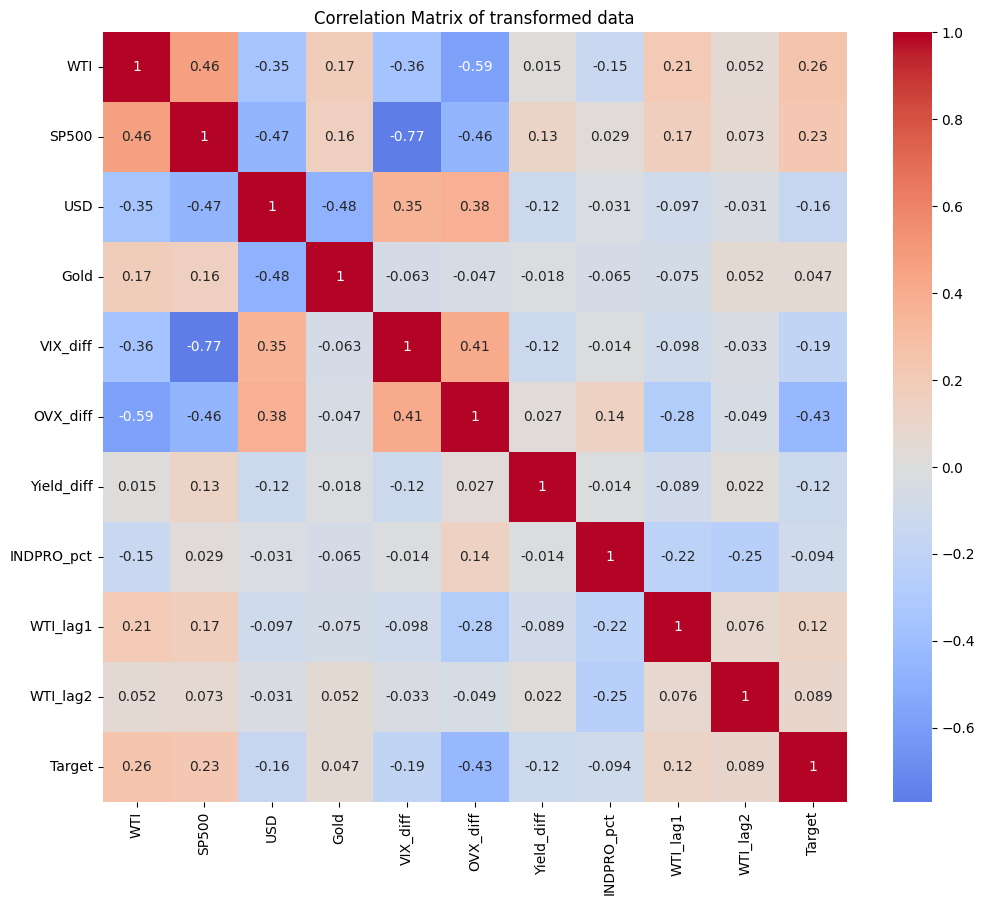

In [232]:
corr = high_vix.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of transformed data')
plt.show()

To evaluate whether crude oil price dynamics respond to changes in markets, we used a partitioning approach (e.g., dividing our data into two regimes) to identify "high" and "low" volatility regimes based on historical changes in the VIX index. We found that correlations between our explanatory variables and future WTI returns are typically quite small or not different from zero during times of little stress (i.e., calm), while they are clearly much larger during periods of heightened stress. Specifically, OVX, S&P500 and VIX demonstrate significantly higher correlations to future oil prices than do other variable combinations when the volatility regime shifts to be higher. Overall, this supports the idea that how oil behaves is dependent upon which regime it is experiencing, as well as the suitability of using machine learning techniques to model those complex interactions.

In [218]:
split = int(len(model_data)*0.8)

train = model_data.iloc[:split]
test = model_data.iloc[split:]